In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as st

# from sklearn.preprocessing import OneHotEncoder

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test, logrank_test

In [2]:
df_desc = pd.read_excel("E Commerce Dataset.xlsx", sheet_name="Data Dict", skiprows=1)
df = pd.read_excel("E Commerce Dataset.xlsx", sheet_name="E Comm")

### Churn

In [ ]:
df.groupby("Churn").describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,4429.0,4.807406,3.644758,0.0,2.0,4.0,8.0,31.0
1,894.0,3.236018,3.415137,0.0,1.0,2.0,5.0,46.0


### Data Arrangements

In [4]:
df_desc.drop(["Unnamed: 0"], axis=1)

,Data,Variable,Discerption
0,E Comm,CustomerID,Unique customer ID
1,E Comm,Churn,Churn Flag
2,E Comm,Tenure,Tenure of customer in organization
3,E Comm,PreferredLoginDevice,Preferred login device of customer
4,E Comm,CityTier,City tier
5,E Comm,WarehouseToHome,Distance in between warehouse to home of customer
6,E Comm,PreferredPaymentMode,Preferred payment method of customer
7,E Comm,Gender,Gender of customer
8,E Comm,HourSpendOnApp,Number of hours spend on mobile application or...
9,E Comm,NumberOfDeviceRegistered,Total number of deceives is registered on part...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [6]:
df[df["Tenure"].isna()]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
6,50007,1,NaN,Phone,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,120.86
7,50008,1,NaN,Phone,1,6.0,CC,Male,3.0,3,Mobile,2,Divorced,3,1,16.0,2.0,2.0,0.0,122.93
9,50010,1,NaN,Phone,1,31.0,Debit Card,Male,2.0,5,Mobile,3,Single,2,0,12.0,1.0,1.0,1.0,122.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2756,52757,0,NaN,Phone,2,8.0,UPI,Female,2.0,3,Mobile,4,Married,5,0,14.0,0.0,1.0,2.0,121.87
2760,52761,0,NaN,Computer,1,7.0,CC,Male,2.0,4,Mobile,3,Married,2,0,12.0,0.0,1.0,0.0,120.08
2773,52774,0,NaN,Phone,3,7.0,CC,Male,3.0,4,Mobile,4,Married,1,0,14.0,2.0,2.0,2.0,122.69
2783,52784,1,NaN,Computer,3,15.0,E wallet,Male,2.0,3,Mobile Phone,5,Married,2,0,19.0,1.0,1.0,0.0,117.90


In [ ]:
churns = pd.DataFrame(df.Churn.value_counts())
churns["Percentage"] = churns["count"] / churns["count"].sum()
churns

,count,Percentage
Churn,,
0,4682,0.831616
1,948,0.168384


In [ ]:
null_churns = pd.DataFrame(df[df.Tenure.isna()].Churn.value_counts())
null_churns["Percentage"] = null_churns["count"] / null_churns["count"].sum()
null_churns

,count,Percentage
Churn,,
0,183,0.693182
1,81,0.306818


The percentage of churn is extremely high among observations with null Tenure. The missing Tenure values are likely from the early customers. But there are plenty of customer data with 0 as Tenure value. So, this is likely MAR(Missing At Random). The other features of data should be able to inform the imputation.

Performing `multiple imputation` to retrieve the missing values.

### Multiple Imputation

In [9]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


def multiple_imputation(
    df: pd.DataFrame, duration_col: str, n_imputations: int
) -> list[pd.DataFrame]:
    RANDOM_STATE = 42
    df = df.drop(["CustomerID"], axis=1)
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    imputed_datasets = []

    for i in range(n_imputations):
        imp = IterativeImputer(
            max_iter=10,
            random_state=RANDOM_STATE + i,
            initial_strategy="median",
        )
        imputed_array = imp.fit_transform(df[numeric_cols])
        imputed_df = df.copy()
        imputed_df[numeric_cols] = imputed_array

        # Enforce non-negativity on duration
        imputed_df[duration_col] = imputed_df[duration_col].clip(lower=0.01)

        imputed_datasets.append(imputed_df)

    return imputed_datasets

In [10]:
# df.drop(["CustomerID"], axis=1, inplace=True)
imputed_datasets = multiple_imputation(df, "Tenure", 10)
df_imp = imputed_datasets[5]

In [11]:
df_imp.head()

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1.0,4.000000,Mobile Phone,3.0,6.0,Debit Card,Female,3.000000,3.0,Laptop & Accessory,2.0,Single,9.0,1.0,11.0,1.0,1.0,5.0,159.93
1,1.0,2.456594,Phone,1.0,8.0,UPI,Male,3.000000,4.0,Mobile,3.0,Single,7.0,1.0,15.0,0.0,1.0,0.0,120.90
2,1.0,3.046899,Phone,1.0,30.0,Debit Card,Male,2.000000,4.0,Mobile,3.0,Single,6.0,1.0,14.0,0.0,1.0,3.0,120.28
3,1.0,0.010000,Phone,3.0,15.0,Debit Card,Male,2.000000,4.0,Laptop & Accessory,5.0,Single,8.0,0.0,23.0,0.0,1.0,3.0,134.07
4,1.0,0.010000,Phone,1.0,12.0,CC,Male,2.621761,3.0,Mobile,5.0,Single,3.0,0.0,11.0,1.0,1.0,3.0,129.60


In [12]:
df_imp.CouponUsed = df_imp.CouponUsed.apply(round)

### Observations

In [13]:
df_imp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Churn                        5630 non-null   float64
 1   Tenure                       5630 non-null   float64
 2   PreferredLoginDevice         5630 non-null   object 
 3   CityTier                     5630 non-null   float64
 4   WarehouseToHome              5630 non-null   float64
 5   PreferredPaymentMode         5630 non-null   object 
 6   Gender                       5630 non-null   object 
 7   HourSpendOnApp               5630 non-null   float64
 8   NumberOfDeviceRegistered     5630 non-null   float64
 9   PreferedOrderCat             5630 non-null   object 
 10  SatisfactionScore            5630 non-null   float64
 11  MaritalStatus                5630 non-null   object 
 12  NumberOfAddress              5630 non-null   float64
 13  Complain          

In [14]:
categorical_variables = df.select_dtypes(include=[np.object_]).columns.tolist()
categorical_variables

['PreferredLoginDevice',
 'PreferredPaymentMode',
 'Gender',
 'PreferedOrderCat',
 'MaritalStatus']

In [15]:
event_variable = df_imp.Churn
time_variable = df_imp.Tenure

In [16]:
df_imp.PreferredLoginDevice.value_counts()

PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

In [17]:
df_imp.PreferredPaymentMode.value_counts()

PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

In [18]:
df_imp.PreferedOrderCat.value_counts()

PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

In [19]:
df_imp.MaritalStatus.value_counts()

MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64

In [20]:
survival_data = pd.get_dummies(df_imp, columns=categorical_variables, drop_first=True)
survival_data.head()

,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,...,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,1.0,4.000000,3.0,6.0,3.000000,3.0,2.0,9.0,1.0,11.0,...,False,False,False,False,True,False,False,False,False,True
1,1.0,2.456594,1.0,8.0,3.000000,4.0,3.0,7.0,1.0,15.0,...,False,True,True,False,False,True,False,False,False,True
2,1.0,3.046899,1.0,30.0,2.000000,4.0,3.0,6.0,1.0,14.0,...,False,False,True,False,False,True,False,False,False,True
3,1.0,0.010000,3.0,15.0,2.000000,4.0,5.0,8.0,0.0,23.0,...,False,False,True,False,True,False,False,False,False,True
4,1.0,0.010000,1.0,12.0,2.621761,3.0,5.0,3.0,0.0,11.0,...,False,False,True,False,False,True,False,False,False,True


In [21]:
survival_data.drop(["Churn", "Tenure"], inplace=True, axis=1)
survival_data = st.add_constant(survival_data, prepend=False)
survival_data.head()

,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,...,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single,const
0,3.0,6.0,3.000000,3.0,2.0,9.0,1.0,11.0,1,1.0,...,False,False,False,True,False,False,False,False,True,1.0
1,1.0,8.0,3.000000,4.0,3.0,7.0,1.0,15.0,0,1.0,...,True,True,False,False,True,False,False,False,True,1.0
2,1.0,30.0,2.000000,4.0,3.0,6.0,1.0,14.0,0,1.0,...,False,True,False,False,True,False,False,False,True,1.0
3,3.0,15.0,2.000000,4.0,5.0,8.0,0.0,23.0,0,1.0,...,False,True,False,True,False,False,False,False,True,1.0
4,1.0,12.0,2.621761,3.0,5.0,3.0,0.0,11.0,1,1.0,...,False,True,False,False,True,False,False,False,True,1.0


### Kaplan-Meier Curve

Text(0, 0.5, 'Probability of Customer Survival')

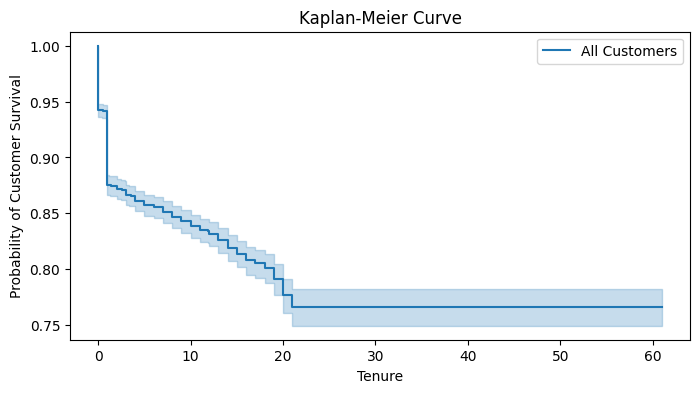

In [ ]:
kmf = KaplanMeierFitter()
kmf.fit(time_variable, event_variable, label="All Customers")

plt.figure(figsize=(8, 4))
kmf.plot()
plt.title("Kaplan-Meier Curve")
plt.xlabel("Tenure")
plt.ylabel("Probability of Customer Survival")

### Log-Rank Tests

In [23]:
categorical_variables

['PreferredLoginDevice',
 'PreferredPaymentMode',
 'Gender',
 'PreferedOrderCat',
 'MaritalStatus']

#### Login Device

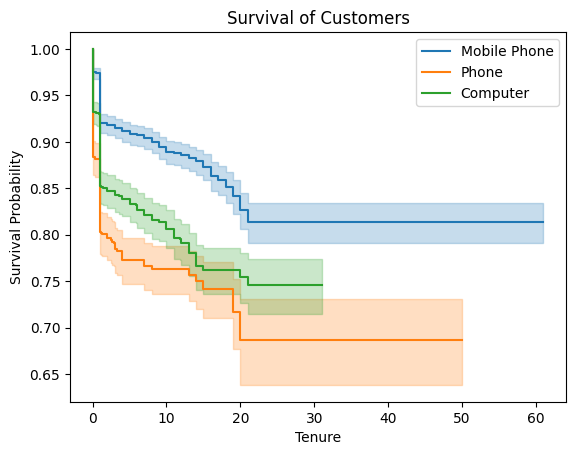

In [24]:
mobile_phone = survival_data["PreferredLoginDevice_Mobile Phone"] == 1
phone = survival_data["PreferredLoginDevice_Phone"] == 1
computer = (survival_data["PreferredLoginDevice_Mobile Phone"] == 0) & (
    survival_data["PreferredLoginDevice_Phone"] == 0
)


plt.figure()
ax = plt.subplot(1, 1, 1)

kmf.fit(
    time_variable[mobile_phone],
    event_observed=event_variable[mobile_phone],
    label="Mobile Phone",
)
plot1 = kmf.plot(ax=ax)

kmf.fit(time_variable[phone], event_observed=event_variable[phone], label="Phone")
plot2 = kmf.plot(ax=ax)

kmf.fit(
    time_variable[computer], event_observed=event_variable[computer], label="Computer"
)
plot3 = kmf.plot(ax=ax)

plt.title("Survival of Customers")
plt.xlabel("Tenure")
plt.ylabel("Survival Probability")

multigroup_logrank = multivariate_logrank_test(
    df_imp.Tenure, df_imp.PreferredLoginDevice, df_imp.Churn, alpha=0.95
)
multigroup_logrank.print_summary()

In [ ]:
phone_v_computer = logrank_test(
    time_variable[phone],
    time_variable[computer],
    event_variable[phone],
    event_variable[computer],
    alpha=0.95,
)
print("Phone v. Computer:", phone_v_computer.p_value)

Phone v. Computer: 0.0011300714320129494


All three categories have very different survival curves.

#### Payment Mode

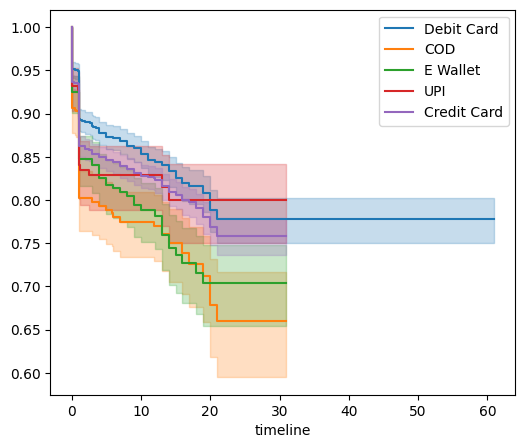

In [ ]:
debit_card = survival_data["PreferredPaymentMode_Debit Card"] == 1
cod = (survival_data["PreferredPaymentMode_COD"] == 1) | (
    survival_data["PreferredPaymentMode_Cash on Delivery"] == 1
)
e_wallet = survival_data["PreferredPaymentMode_E wallet"] == 1
upi = survival_data["PreferredPaymentMode_UPI"] == 1

credit_card = survival_data["PreferredPaymentMode_Debit Card"] == 0 & (
    survival_data["PreferredPaymentMode_COD"] == 0
) & (survival_data["PreferredPaymentMode_Cash on Delivery"] == 0) & (
    survival_data["PreferredPaymentMode_E wallet"] == 0
) & (
    survival_data["PreferredPaymentMode_UPI"] == 0
)

plt.figure(figsize=(6, 5))
ax = plt.subplot(1, 1, 1)

kmf.fit(
    time_variable[debit_card],
    event_observed=event_variable[debit_card],
    label="Debit Card",
)
kmf.plot(ax=ax)

kmf.fit(time_variable[cod], event_observed=event_variable[cod], label="COD")
kmf.plot(ax=ax)

kmf.fit(
    time_variable[e_wallet], event_observed=event_variable[e_wallet], label="E Wallet"
)
kmf.plot(ax=ax)

kmf.fit(time_variable[upi], event_observed=event_variable[upi], label="UPI")
kmf.plot(ax=ax)

kmf.fit(
    time_variable[credit_card],
    event_observed=event_variable[credit_card],
    label="Credit Card",
)
kmf.plot(ax=ax)

payment_mode_logrank = multivariate_logrank_test(
    df_imp.Tenure, df_imp.PreferredPaymentMode, df_imp.Churn, alpha=0.95
)
payment_mode_logrank.print_summary()

In [ ]:
cod_v_ewallet = logrank_test(
    time_variable[cod],
    time_variable[e_wallet],
    event_variable[cod],
    event_variable[e_wallet],
    alpha=0.95,
)
upi_v_cc = logrank_test(
    time_variable[upi],
    time_variable[credit_card],
    event_variable[upi],
    event_variable[credit_card],
    alpha=0.95,
)
credit_v_debit = logrank_test(
    time_variable[credit_card],
    time_variable[debit_card],
    event_variable[credit_card],
    event_variable[debit_card],
    alpha=0.95,
)
credit_v_ewallet = logrank_test(
    time_variable[credit_card],
    time_variable[e_wallet],
    event_variable[credit_card],
    event_variable[e_wallet],
    alpha=0.95,
)

print(
    "COD v. E Wallet:",
    cod_v_ewallet.p_value,
    "\nUPI v. Credit Card:",
    upi_v_cc.p_value,
    "\nCredit Card v. Debit Card:",
    credit_v_debit.p_value,
    "\nCredit Card v. E Wallet:",
    credit_v_ewallet.p_value,
)

COD v. E Wallet: 0.30817969094990394 
UPI v. Credit Card: 0.9237368363019537 
Credit Card v. Debit Card: 0.013059017337906573 
Credit Card v. E Wallet: 0.012066194232375555


1. `COD` and `E Wallet` payment methods have similar survival curves.
2. `UPI` and `Credit Card` payment methods have extremely similar survival curves.
3. `Credit Card` and `Debit Card` payment methods have different survival curves.
4. `Credit Card` and `E Wallet` payment methods have different survival curves.

The distinct groups are `Debit Card`, `UPI&CreditCard` and `COD&EWallet`.

#### Gender

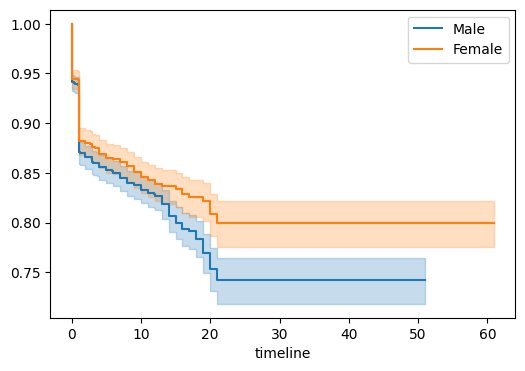

In [ ]:
male = survival_data.Gender_Male == 1
female = survival_data.Gender_Male == 0

plt.figure(figsize=(6, 4))
ax = plt.subplot(1, 1, 1)

kmf.fit(time_variable[male], event_observed=event_variable[male], label="Male")
kmf.plot(ax=ax)

kmf.fit(time_variable[female], event_observed=event_variable[female], label="Female")
kmf.plot(ax=ax)

gender_logrank = logrank_test(
    time_variable[male],
    time_variable[female],
    event_variable[male],
    event_variable[female],
    alpha=0.95,
)
gender_logrank.print_summary()

`Male` and `Female` customers' survival curves are apparently different.

#### Order Category

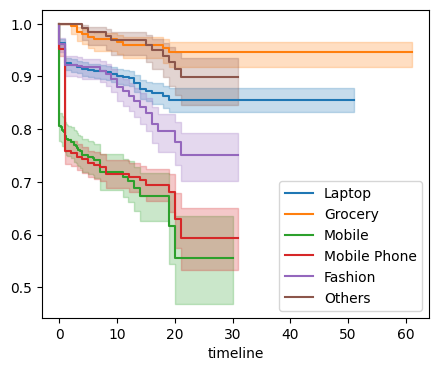

In [ ]:
laptop = survival_data["PreferedOrderCat_Laptop & Accessory"] == 1
grocery = survival_data["PreferedOrderCat_Grocery"] == 1
mobile = survival_data["PreferedOrderCat_Mobile"] == 1
mobile_phone = survival_data["PreferedOrderCat_Mobile Phone"] == 1
others = survival_data["PreferedOrderCat_Others"] == 1
fashion = (
    (survival_data["PreferedOrderCat_Laptop & Accessory"] == 0)
    & (survival_data["PreferedOrderCat_Grocery"] == 0)
    & (survival_data["PreferedOrderCat_Mobile"] == 0)
    & (survival_data["PreferedOrderCat_Mobile Phone"] == 0)
    & (survival_data["PreferedOrderCat_Others"] == 0)
)

plt.figure(figsize=(5, 4))
ax = plt.subplot(1, 1, 1)

kmf.fit(time_variable[laptop], event_observed=event_variable[laptop], label="Laptop")
kmf.plot(ax=ax)

kmf.fit(time_variable[grocery], event_observed=event_variable[grocery], label="Grocery")
kmf.plot(ax=ax)

kmf.fit(time_variable[mobile], event_observed=event_variable[mobile], label="Mobile")
kmf.plot(ax=ax)

kmf.fit(
    time_variable[mobile_phone],
    event_observed=event_variable[mobile_phone],
    label="Mobile Phone",
)
kmf.plot(ax=ax)

kmf.fit(time_variable[fashion], event_observed=event_variable[fashion], label="Fashion")
kmf.plot(ax=ax)

kmf.fit(time_variable[others], event_observed=event_variable[others], label="Others")
kmf.plot(ax=ax)

order_category_logrank = multivariate_logrank_test(
    df_imp.Tenure, df_imp.PreferedOrderCat, df_imp.Churn, alpha=0.95
)
order_category_logrank.print_summary()

In [ ]:
others_v_grocery = logrank_test(
    time_variable[others],
    time_variable[grocery],
    event_variable[others],
    event_variable[grocery],
    alpha=0.95,
)
laptop_v_fashion = logrank_test(
    time_variable[laptop],
    time_variable[fashion],
    event_variable[laptop],
    event_variable[fashion],
    alpha=0.95,
)
mobilephone_v_mobile = logrank_test(
    time_variable[mobile_phone],
    time_variable[mobile],
    event_variable[mobile_phone],
    event_variable[mobile],
    alpha=0.95,
)

print("Others v. Grocery:", others_v_grocery.p_value)
print("Laptop v. Fashion:", laptop_v_fashion.p_value)
print("Mobile Phone v. Mobile:", mobilephone_v_mobile.p_value)

Others v. Grocery: 0.14604372072649122
Laptop v. Fashion: 0.009079766411996398
Mobile Phone v. Mobile: 0.0743264471013395


1. `Grocery` and `Others` categories have similar survival curve.
2. `Laptop` and `Fashion` categories are different in survival curve.
3. `Mobile Phone` and `Mobile` categories have similar survival curve.

Distinct groups are `Grocery&Others`, `Laptop`, `Fashion` and `Mobile`.

#### Marital Status

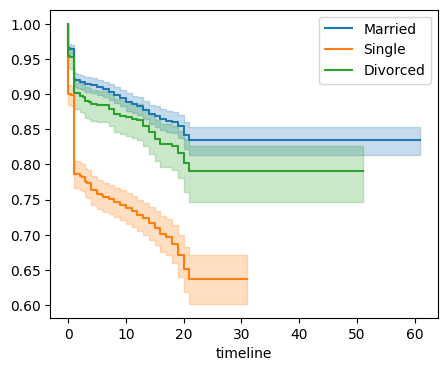

In [ ]:
married = survival_data["MaritalStatus_Married"] == 1
single = survival_data["MaritalStatus_Single"] == 1
divorced = (survival_data["MaritalStatus_Married"] == 0) & (
    survival_data["MaritalStatus_Single"] == 0
)

plt.figure(figsize=(5, 4))
ax = plt.subplot(1, 1, 1)

kmf.fit(time_variable[married], event_observed=event_variable[married], label="Married")
kmf.plot(ax=ax)

kmf.fit(time_variable[single], event_observed=event_variable[single], label="Single")
kmf.plot(ax=ax)

kmf.fit(
    time_variable[divorced], event_observed=event_variable[divorced], label="Divorced"
)
kmf.plot(ax=ax)

marital_status_logrank = multivariate_logrank_test(
    df_imp.Tenure, df_imp.MaritalStatus, df_imp.Churn, alpha=0.95
)
marital_status_logrank.print_summary()

In [ ]:
married_v_divorced = logrank_test(
    time_variable[married],
    time_variable[divorced],
    event_variable[married],
    event_variable[divorced],
    alpha=0.95,
)
print("Married v. Divorced:", married_v_divorced.p_value)

Married v. Divorced: 0.021112827266013982


1. `Married` customers has a different survival curve than `Divorced` ones.

All three categories are distinct.

### Survival Regression

In [33]:
df_imp.columns

Index(['Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

In [34]:
for v in categorical_variables:
    print(v)
    print(df_imp[v].unique())
    print("-" * 20)

PreferredLoginDevice
['Mobile Phone' 'Phone' 'Computer']
--------------------
PreferredPaymentMode
['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']
--------------------
Gender
['Female' 'Male']
--------------------
PreferedOrderCat
['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']
--------------------
MaritalStatus
['Single' 'Divorced' 'Married']
--------------------


In [35]:
categorical_variables

['PreferredLoginDevice',
 'PreferredPaymentMode',
 'Gender',
 'PreferedOrderCat',
 'MaritalStatus']

In [36]:
df_imp.columns

Index(['Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

### Data Preparation

In [ ]:
def data_preparation(filepath, sheet_name=None, is_excel=False):

    df = (
        pd.read_excel(filepath, sheet_name=sheet_name)
        if is_excel
        else pd.read_csv(filepath)
    )
    df = multiple_imputation(df, "Tenure", n_imputations=10)[5]
    df.drop(
        [
            "HourSpendOnApp",
            "OrderAmountHikeFromlastYear",
            "CouponUsed",
            "OrderCount",
            "WarehouseToHome",
            "NumberOfAddress",
            "CashbackAmount",
            "DaySinceLastOrder",
        ],
        axis=1,
        inplace=True,
    )
    df.PreferredLoginDevice = df.PreferredLoginDevice.replace({"Mobile Phone": "Phone"})
    df.PreferredPaymentMode = df.PreferredPaymentMode.replace(
        {
            "CC": "UPI&CreditCard",
            "Credit Card": "UPI&CreditCard",
            "UPI": "UPI&CreditCard",
            "COD": "COD&EWallet",
            "Cash on Delivery": "COD&EWallet",
            "E wallet": "COD&EWallet",
        }
    )
    df.MaritalStatus = df.MaritalStatus.replace(
        {"Divorced": "DivorcedOrMarried", "Married": "DivorcedOrMarried"}
    )
    df.PreferedOrderCat = df.PreferedOrderCat.replace(
        {
            "Grocery": "Grocery&Others",
            "Others": "Grocery&Others",
            "Mobile Phone": "Mobile",
        }
    )

    df = pd.get_dummies(
        df,
        columns=[
            "PreferredLoginDevice",
            "PreferredPaymentMode",
            "Gender",
            "PreferedOrderCat",
            "MaritalStatus",
        ],
        drop_first=True,
        dtype=float,
    )
    return df

In [ ]:
regression_df = data_preparation(
    "E Commerce Dataset.xlsx", sheet_name="E Comm", is_excel=True
)
regression_df.head()

,Churn,Tenure,CityTier,NumberOfDeviceRegistered,SatisfactionScore,Complain,PreferredLoginDevice_Phone,PreferredPaymentMode_Debit Card,PreferredPaymentMode_UPI&CreditCard,Gender_Male,PreferedOrderCat_Grocery&Others,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,MaritalStatus_Single
0,1.0,4.000000,3.0,3.0,2.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1.0,2.456594,1.0,4.0,3.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
2,1.0,3.046899,1.0,4.0,3.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0
3,1.0,0.010000,3.0,4.0,5.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
4,1.0,0.010000,1.0,3.0,5.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0


In [56]:
regression_df.columns

Index(['Churn', 'Tenure', 'CityTier', 'NumberOfDeviceRegistered',
       'SatisfactionScore', 'Complain', 'PreferredLoginDevice_Phone',
       'PreferredPaymentMode_Debit Card',
       'PreferredPaymentMode_UPI&CreditCard', 'Gender_Male',
       'PreferedOrderCat_Grocery&Others',
       'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile',
       'MaritalStatus_Single'],
      dtype='object')

### Fitting Cox's Hazard Model (Initial Fit)

In [57]:
cph = CoxPHFitter()
cph.fit(regression_df, duration_col="Tenure", event_col="Churn")

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 5630 total observations, 4682 right-censored observations>
             duration col = 'Tenure'
                event col = 'Churn'
      baseline estimation = breslow
   number of observations = 5630
number of events observed = 948
   partial log-likelihood = -7289.67
         time fit was run = 2026-03-01 19:26:37 UTC

---
                                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                            
CityTier                             0.38      1.46      0.04            0.30            0.45                1.35                1.58
NumberOfDeviceRegistered             0.20      1.22      0.03            0.13            0.27                1.14                1.31
SatisfactionScore                    0.22      1.25      0.02            0.17            0.27                1.19                1.31
Complain                             1.21      3.35      0.07            1.08            1.34                2.94                3.80
PreferredLoginDevice_Phone          -0.36      0.70      0.07           -0.50           -0.23                0.61                0.80
PreferredPaymentMode_Debit Card     -0.32      0.73      0.09           -0.49           -0.15                0.61                0.86
PreferredPaymentMode_UPI&CreditCard -0.37      0.69      0.09           -0.54           -0.19                0.58                0.83
Gender_Male                          0.24      1.27      0.07            0.11            0.37                1.11                1.45
PreferedOrderCat_Grocery&Others     -1.16      0.32      0.18           -1.51           -0.80                0.22                0.45
PreferedOrderCat_Laptop & Accessory -0.26      0.77      0.11           -0.48           -0.04                0.62                0.96
PreferedOrderCat_Mobile              1.17      3.22      0.10            0.97            1.37                2.64                3.93
MaritalStatus_Single                 0.84      2.33      0.07            0.72            0.97                2.04                2.65

                                     cmp to     z      p  -log2(p)
covariate                                                         
CityTier                               0.00  9.64 <0.005     70.67
NumberOfDeviceRegistered               0.00  5.84 <0.005     27.53
SatisfactionScore                      0.00  9.04 <0.005     62.42
Complain                               0.00 18.43 <0.005    249.43
PreferredLoginDevice_Phone             0.00 -5.24 <0.005     22.54
PreferredPaymentMode_Debit Card        0.00 -3.70 <0.005     12.16
PreferredPaymentMode_UPI&CreditCard    0.00 -4.07 <0.005     14.35
Gender_Male                            0.00  3.55 <0.005     11.35
PreferedOrderCat_Grocery&Others        0.00 -6.32 <0.005     31.79
PreferedOrderCat_Laptop & Accessory    0.00 -2.29   0.02      5.49
PreferedOrderCat_Mobile                0.00 11.45 <0.005     98.40
MaritalStatus_Single                   0.00 12.80 <0.005    122.16
---
Concordance = 0.81
Partial AIC = 14603.34
log-likelihood ratio test = 1209.69 on 12 df
-log2(p) of ll-ratio test = 833.30

##### Summary:
All chosen variables are having significant contribution to the fit

<Axes: xlabel='log(HR) (95% CI)'>

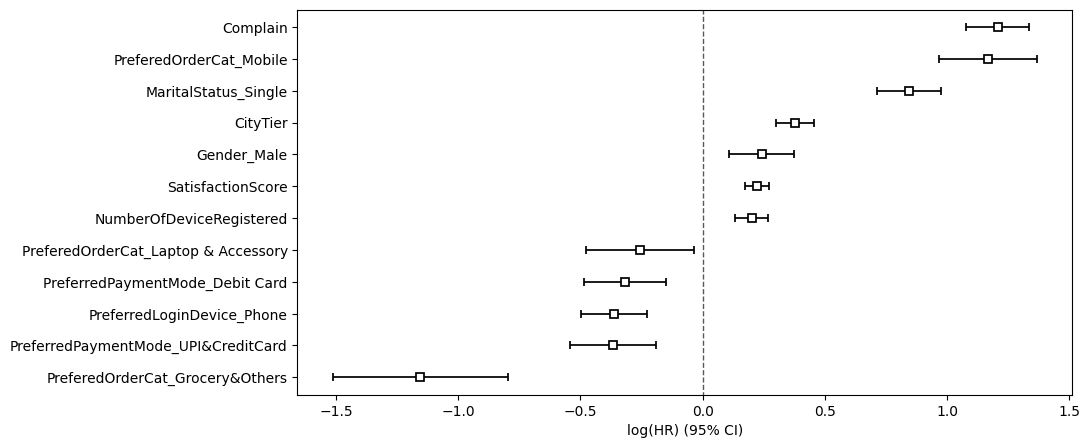

In [58]:
fig, ax = plt.subplots(figsize=(10, 5))
cph.plot(ax=ax)

PreferredOrderCat variables are occupying wide confidence intervals

In [59]:
from lifelines.statistics import proportional_hazard_test

results = proportional_hazard_test(cph, regression_df, time_transform="rank")
results.print_summary()

NumberOfDeviceRegistered, PreferredOrderCat and Complain variables are showing trend with time. PH Test violated.

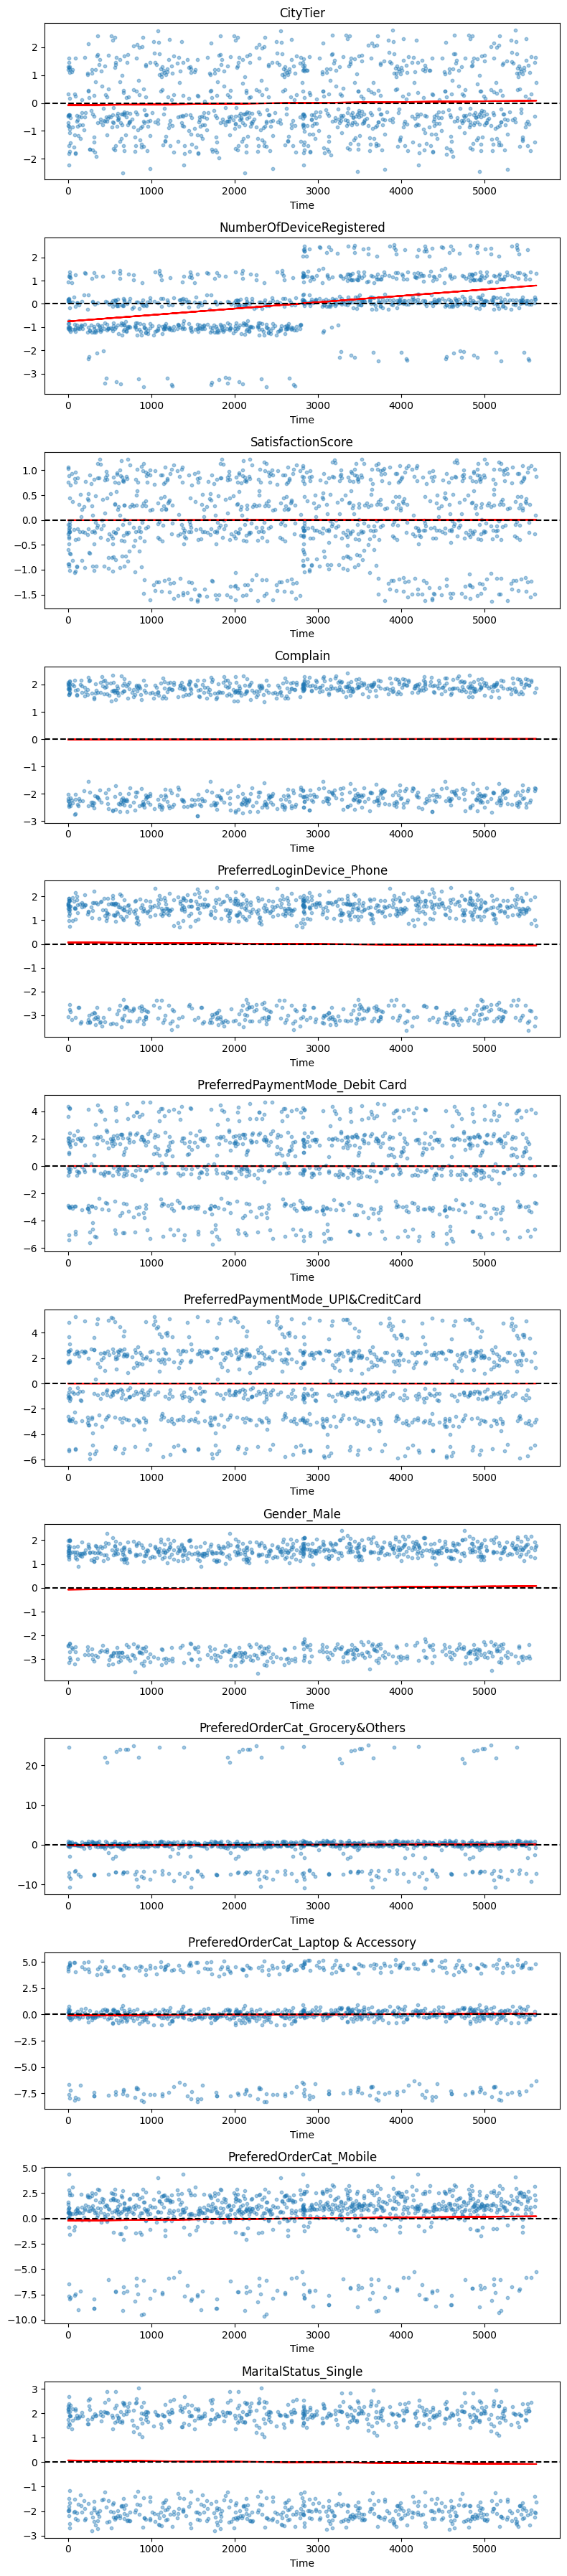

In [60]:
schoenfeld_residuals = cph.compute_residuals(regression_df, kind="scaled_schoenfeld")

# Plot each covariate
covariates = schoenfeld_residuals.columns.tolist()
fig, axes = plt.subplots(
    nrows=len(covariates), ncols=1, figsize=(8, len(covariates) * 3)
)

for covariate, ax in zip(covariates, axes):
    ax.scatter(
        schoenfeld_residuals.index, schoenfeld_residuals[covariate], alpha=0.4, s=10
    )
    # Smoothed trend line
    from scipy.stats import pearsonr

    z = np.polyfit(schoenfeld_residuals.index, schoenfeld_residuals[covariate], 1)
    p = np.poly1d(z)
    ax.plot(schoenfeld_residuals.index, p(schoenfeld_residuals.index), color="red")
    ax.axhline(y=0, color="black", linestyle="--")
    ax.set_title(covariate)
    ax.set_xlabel("Time")

plt.tight_layout()
plt.show()

`NumberOfDeviceRegistered` has a upward trend with time. `PreferredOrderCat` variables are also showing trends.

### Data Preparation (Part 2)

In [80]:
df_imp.NumberOfDeviceRegistered.describe()

count    5630.000000
mean        3.688988
std         1.023999
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         6.000000
Name: NumberOfDeviceRegistered, dtype: float64

In [93]:
def data_preparation2(filepath, sheet_name=None, is_excel=False):

    df = (
        pd.read_excel(filepath, sheet_name=sheet_name)
        if is_excel
        else pd.read_csv(filepath)
    )
    df = multiple_imputation(df, "Tenure", n_imputations=10)[5]
    df.drop(
        [
            "HourSpendOnApp",
            "OrderAmountHikeFromlastYear",
            "CouponUsed",
            "PreferedOrderCat",
            "OrderCount",
            "WarehouseToHome",
            "NumberOfAddress",
            "CashbackAmount",
            "DaySinceLastOrder",
            "Gender",
            "CityTier",
        ],
        axis=1,
        inplace=True,
    )
    df.PreferredLoginDevice = df.PreferredLoginDevice.replace({"Mobile Phone": "Phone"})
    df.PreferredPaymentMode = df.PreferredPaymentMode.replace(
        {
            "CC": "UPI&CreditCard",
            "Credit Card": "UPI&CreditCard",
            "UPI": "UPI&CreditCard",
            "COD": "COD&EWallet",
            "Cash on Delivery": "COD&EWallet",
            "E wallet": "COD&EWallet",
        }
    )
    df.MaritalStatus = df.MaritalStatus.replace(
        {"Divorced": "DivorcedOrMarried", "Married": "DivorcedOrMarried"}
    )
    df.NumberOfDeviceRegistered = df.NumberOfDeviceRegistered.clip(upper=6)

    df = pd.get_dummies(
        df,
        columns=[
            "PreferredLoginDevice",
            "PreferredPaymentMode",
            "MaritalStatus",
        ],
        drop_first=True,
        dtype=float,
    )
    return df

In [ ]:
regression_df2 = data_preparation2(
    "E Commerce Dataset.xlsx", sheet_name="E Comm", is_excel=True
)
regression_df2.head()

,Churn,Tenure,NumberOfDeviceRegistered,SatisfactionScore,Complain,PreferredLoginDevice_Phone,PreferredPaymentMode_Debit Card,PreferredPaymentMode_UPI&CreditCard,MaritalStatus_Single
0,1.0,4.000000,3.0,2.0,1.0,1.0,1.0,0.0,1.0
1,1.0,2.456594,4.0,3.0,1.0,1.0,0.0,1.0,1.0
2,1.0,3.046899,4.0,3.0,1.0,1.0,1.0,0.0,1.0
3,1.0,0.010000,4.0,5.0,0.0,1.0,1.0,0.0,1.0
4,1.0,0.010000,3.0,5.0,0.0,1.0,0.0,1.0,1.0


### Fitting Cox's Hazard (With dropping PreferredOrderCat and stratifying NumberOfDeviceRegistered)

In [95]:
cph2 = CoxPHFitter()
cph2.fit(
    regression_df2,
    duration_col="Tenure",
    event_col="Churn",
    strata=[
        "NumberOfDeviceRegistered",
    ],
    # observed=True,
)

cph2.print_summary()

<lifelines.CoxPHFitter: fitted with 5630 total observations, 4682 right-censored observations>
             duration col = 'Tenure'
                event col = 'Churn'
                   strata = NumberOfDeviceRegistered
      baseline estimation = breslow
   number of observations = 5630
number of events observed = 948
   partial log-likelihood = -6225.77
         time fit was run = 2026-03-01 20:33:18 UTC

---
                                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                            
SatisfactionScore                    0.21      1.24      0.02            0.16            0.26                1.18                1.30
Complain                             1.18      3.26      0.07            1.06            1.31                2.87                3.71
PreferredLoginDevice_Phone          -0.35      0.71      0.07           -0.48           -0.21                0.62                0.81
PreferredPaymentMode_Debit Card     -0.49      0.61      0.08           -0.65           -0.33                0.52                0.72
PreferredPaymentMode_UPI&CreditCard -0.56      0.57      0.08           -0.72           -0.40                0.49                0.67
MaritalStatus_Single                 0.93      2.54      0.07            0.80            1.06                2.23                2.88

                                     cmp to     z      p  -log2(p)
covariate                                                         
SatisfactionScore                      0.00  8.65 <0.005     57.42
Complain                               0.00 18.13 <0.005    241.68
PreferredLoginDevice_Phone             0.00 -5.00 <0.005     20.71
PreferredPaymentMode_Debit Card        0.00 -6.00 <0.005     28.93
PreferredPaymentMode_UPI&CreditCard    0.00 -6.71 <0.005     35.54
MaritalStatus_Single                   0.00 14.26 <0.005    150.84
---
Concordance = 0.73
Partial AIC = 12463.53
log-likelihood ratio test = 632.96 on 6 df
-log2(p) of ll-ratio test = 440.96

Each variable is statistically important. The model ranks subjects by their risk with 73% accuracy.

<Axes: xlabel='log(HR) (95% CI)'>

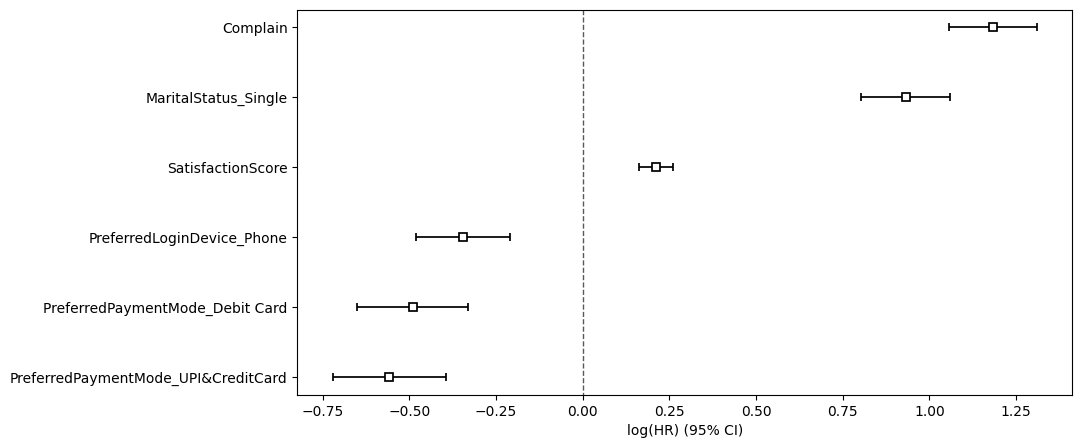

In [96]:
fig, ax = plt.subplots(figsize=(10, 5))
cph2.plot(ax=ax)

In [97]:
results2 = proportional_hazard_test(cph2, regression_df2, time_transform="rank")
results2.print_summary()

All of the p-values are > 0.05. PH test holds.

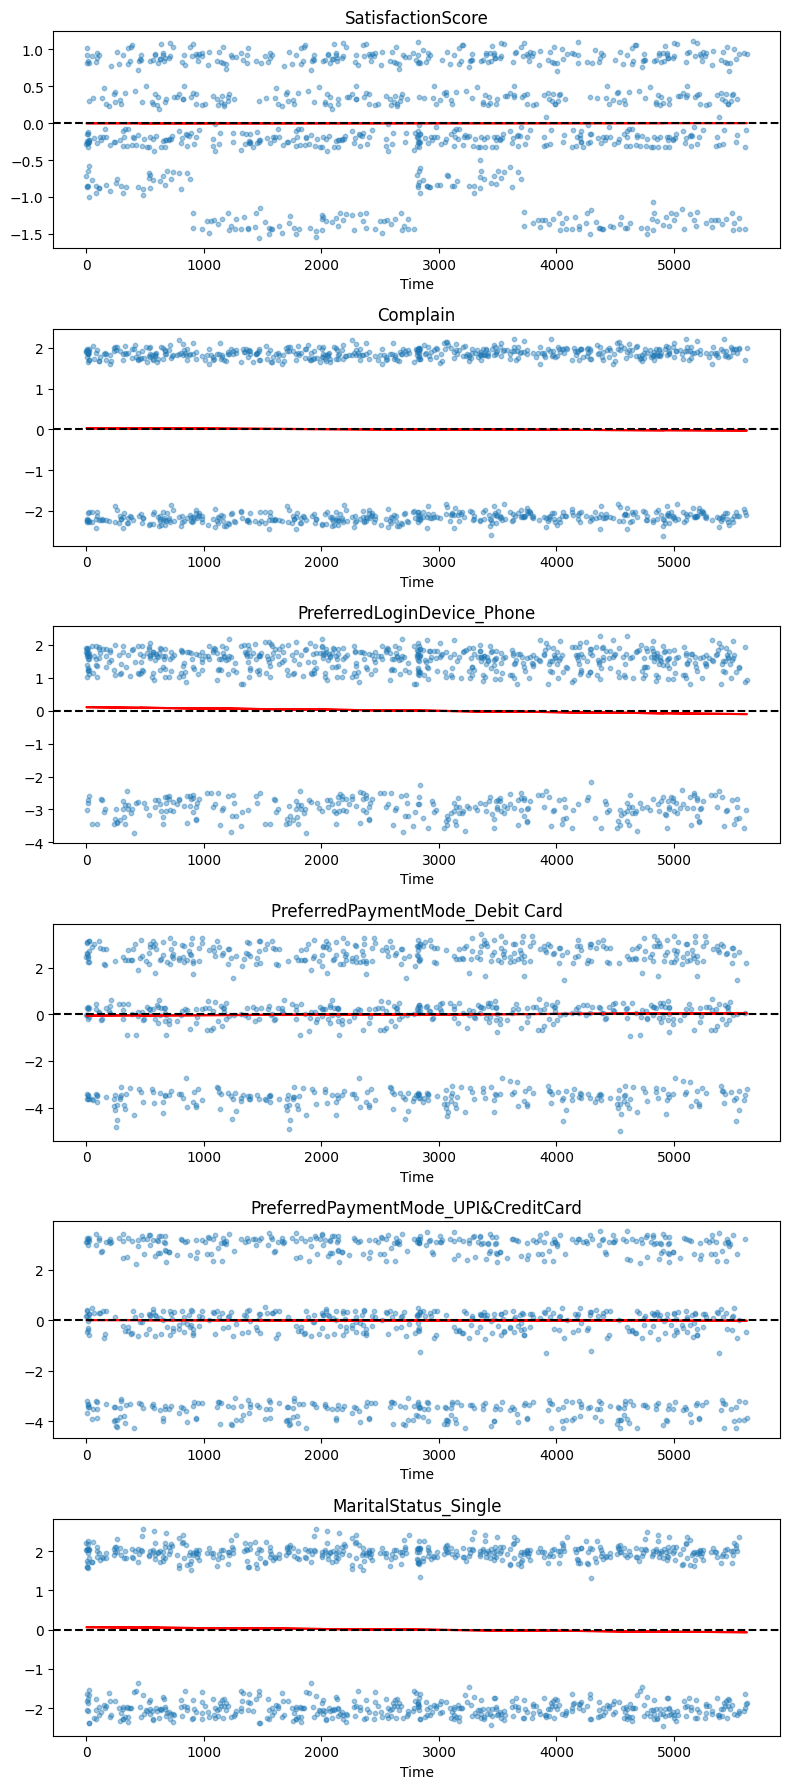

In [98]:
schoenfeld_residuals = cph2.compute_residuals(regression_df2, kind="scaled_schoenfeld")

# Plot each covariate
covariates = schoenfeld_residuals.columns.tolist()
fig, axes = plt.subplots(
    nrows=len(covariates), ncols=1, figsize=(8, len(covariates) * 3)
)

for covariate, ax in zip(covariates, axes):
    ax.scatter(
        schoenfeld_residuals.index, schoenfeld_residuals[covariate], alpha=0.4, s=10
    )
    # Smoothed trend line
    from scipy.stats import pearsonr

    z = np.polyfit(schoenfeld_residuals.index, schoenfeld_residuals[covariate], 1)
    p = np.poly1d(z)
    ax.plot(schoenfeld_residuals.index, p(schoenfeld_residuals.index), color="red")
    ax.axhline(y=0, color="black", linestyle="--")
    ax.set_title(covariate)
    ax.set_xlabel("Time")

plt.tight_layout()
plt.show()

### Test

In [105]:
test_id = regression_df2.sample(1)

Text(0.5, 1.0, 'Cumulative Hazard Over Time')

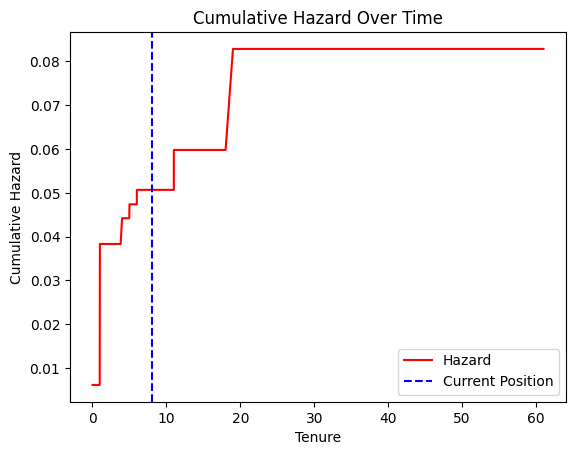

In [106]:
fig, ax = plt.subplots()
cph2.predict_cumulative_hazard(test_id).plot(ax=ax, color="red")
plt.axvline(x=test_id.Tenure.values[0], color="blue", linestyle="--")
plt.legend(labels=["Hazard", "Current Position"])
ax.set_xlabel("Tenure", size=10)
ax.set_ylabel("Cumulative Hazard", size=10)
ax.set_title("Cumulative Hazard Over Time")

Text(0.5, 1.0, 'Survival Probability Over Time')

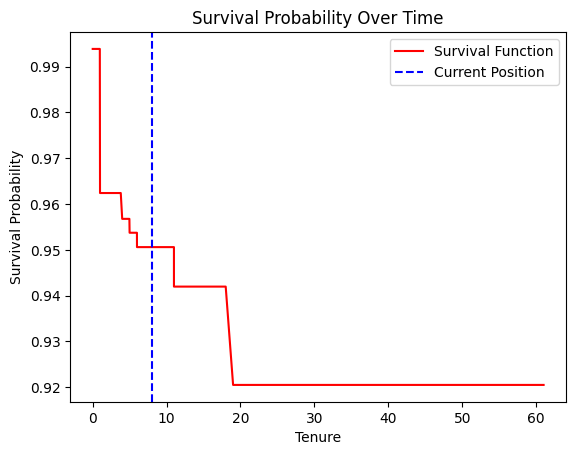

In [107]:
fig, ax = plt.subplots()
cph2.predict_survival_function(test_id).plot(ax=ax, color="red")
plt.axvline(x=test_id.Tenure.values[0], color="blue", linestyle="--")
plt.legend(labels=["Survival Function", "Current Position"])
ax.set_xlabel("Tenure", size=10)
ax.set_ylabel("Survival Probability", size=10)
ax.set_title("Survival Probability Over Time")